# Livrable 3 — Captioning d'images (Prototype prêt à tester)

Ce notebook implémente un pipeline **CNN encoder + RNN decoder avec attention** pour le *image captioning*, en s'appuyant sur un **modèle pré‑entraîné** côté vision pour extraire des *features* (EfficientNetB0 par défaut). Il est structuré pour répondre aux exigences du livrable 3 :
1) **Schéma et description** de l'architecture (encoder CNN + decoder RNN avec attention)
2) **Pré‑traitement** des images et du texte (tokenizer, padding, vocabulaire)
3) **Code de l'architecture** et **boucle d'entraînement**
4) **Courbes d'apprentissage** + **exemples d'annotations sur images de test**

> ⚠️ Conseil: démarrez sur un petit sous‑ensemble (quelques centaines d'images) pour valider le pipeline, puis montez en charge.


## 0) Prérequis & Configuration
- TensorFlow 2.x
- (Option 1) **TFDS** pour charger *MS COCO Captions* (`coco_captions`) — nécessite la connexion internet au premier téléchargement.
- (Option 2) **Dataset local** avec structure: `images/` et un fichier `captions.json` de forme `{image_path: ["caption1", "caption2", ...], ...}`.


## 1) Imports & config

In [2]:
# 1) Imports & config
import os, json, random, pathlib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# GPU optionnel (désactive la pré-allocation mémoire agressive)
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 32
MAX_LEN    = 30          # longueur max des légendes (padding)
VOCAB_SIZE = 10000       # taille vocab (Top-K)
OOV_TOKEN  = "<unk>"
START_TOKEN= "<start>"
END_TOKEN  = "<end>"

# Chemins dataset local (COCO)
DATA_ROOT     = pathlib.Path("data/DatasetLiv3/archive/coco2014")
ANNOT_TRAIN   = DATA_ROOT / "annotations/captions_train2014.json"
ANNOT_VAL     = DATA_ROOT / "annotations/captions_val2014.json"
IMG_TRAIN_DIR = DATA_ROOT / "images/train2014"
IMG_VAL_DIR   = DATA_ROOT / "images/val2014"

# InceptionV3 → 299x299
image_size = (299, 299)
print("✅ image_size:", image_size)


✅ image_size: (299, 299)


## 2) Charger annotations COCO & mapping fichiers→captions

In [3]:
# 2) Charger annotations COCO & mapping fichiers→captions
with open(ANNOT_TRAIN, "r") as f:
    train_data = json.load(f)
with open(ANNOT_VAL, "r") as f:
    val_data   = json.load(f)

id2file_train = {img["id"]: img["file_name"] for img in train_data["images"]}
id2file_val   = {img["id"]: img["file_name"] for img in val_data["images"]}

def build_caption_map(data, id2file):
    cap_map = {}
    for ann in data["annotations"]:
        fname = id2file[ann["image_id"]]
        cap_map.setdefault(fname, []).append(ann["caption"])
    return cap_map

train_caps = build_caption_map(train_data, id2file_train)
val_caps   = build_caption_map(val_data,   id2file_val)

print(f"📊 train images: {len(train_caps)} | val images: {len(val_caps)}")


📊 train images: 82783 | val images: 40504


## 2) Choix du CNN pré‑entraîné (Encoder Visuel)
Par défaut **EfficientNetB0** (rapide/efficace). Vous pouvez basculer vers `InceptionV3` ou `ResNet50`.
`image_size` doit correspondre au *preprocess_input* du backbone choisi.

In [4]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.utils import get_file

# 🔧 Téléchargement manuel des bons poids ImageNet (RGB)
url = "https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5"
weights_path = get_file("efficientnetb0_notop_rgb.h5", origin=url, cache_subdir="models")

print("✅ Poids ImageNet RGB téléchargés depuis le dépôt officiel Keras.")

# 🧠 Charger EfficientNetB0 sans erreur
base_cnn = EfficientNetB0(
    include_top=False,
    weights=None,              # on charge sans poids pour éviter le bug
    pooling='avg',
    input_shape=(224, 224, 3)
)

# ✅ Charger manuellement les bons poids RGB
base_cnn.load_weights(weights_path)

# 🔒 Geler le modèle
base_cnn.trainable = False

# 🔧 Ajouter la couche Dense finale
encoder = tf.keras.Sequential([
    base_cnn,
    tf.keras.layers.Dense(512, activation='relu')
], name="cnn_encoder")

encoder.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✅ Poids ImageNet RGB téléchargés depuis le dépôt officiel Keras.


Model: "cnn_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,705,443 (17.95 MB)

 Trainable params: 655,872 (2.50 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
# ✅ Préprocessing spécifique à EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
import numpy as np

def Preproc(x: np.ndarray) -> np.ndarray:
    """
    Applique le preprocessing adapté à EfficientNetB0 :
    - Convertit l'image en float32
    - Normalise les valeurs entre [-1, 1]
    """
    x = x.astype(np.float32)
    x = efficientnet_preprocess(x)
    return x


## 3) Chargement des données
### Dataset local custom
Placez vos images sous `data/images/` et un fichier `data/captions.json` (mapping image→liste de captions).

📊 82783 images d'entraînement, 40504 images de validation chargées.
✅ Taille d'image utilisée pour le dataset : (224, 224)
✅ Dataset COCO local chargé et prêt à l’entraînement !


2025-10-20 08:51:50.600297: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 909 of 1024
2025-10-20 08:51:52.007224: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


📝 Exemple de légende : a person surfing on a big wave on the beach
📐 Taille d'image batch : (32, 224, 224, 3)


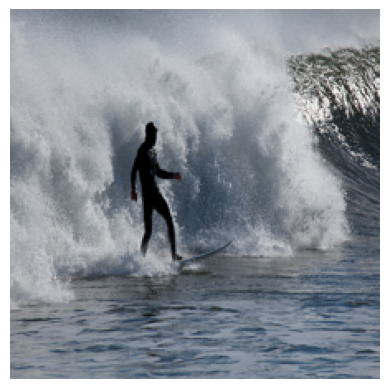

2025-10-20 08:51:52.746967: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
import json, os, random, pathlib
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 📁 Répertoire du dataset COCO local
DATA_ROOT = pathlib.Path("data/DatasetLiv3/archive/coco2014")
ANNOT_TRAIN = DATA_ROOT / "annotations/captions_train2014.json"
ANNOT_VAL = DATA_ROOT / "annotations/captions_val2014.json"
IMG_TRAIN_DIR = DATA_ROOT / "images/train2014"
IMG_VAL_DIR = DATA_ROOT / "images/val2014"

# 🔍 Charger les fichiers JSON
with open(ANNOT_TRAIN, 'r') as f:
    train_data = json.load(f)
with open(ANNOT_VAL, 'r') as f:
    val_data = json.load(f)

# 🔗 Construire le mapping image_id -> nom de fichier
id2file_train = {img["id"]: img["file_name"] for img in train_data["images"]}
id2file_val = {img["id"]: img["file_name"] for img in val_data["images"]}

# 🗺️ Construire le mapping filename -> [liste de captions]
def build_caption_map(data, id2file):
    cap_map = {}
    for ann in data["annotations"]:
        fname = id2file[ann["image_id"]]
        cap_map.setdefault(fname, []).append(ann["caption"])
    return cap_map

train_caps = build_caption_map(train_data, id2file_train)
val_caps = build_caption_map(val_data, id2file_val)

print(f"📊 {len(train_caps)} images d'entraînement, {len(val_caps)} images de validation chargées.")

# ✅ Adapter automatiquement la taille selon le backbone utilisé
try:
    if "inception" in encoder.layers[0].name.lower():
        image_size = (299, 299)
    else:
        image_size = (224, 224)
except Exception:
    image_size = (299, 299)

print(f"✅ Taille d'image utilisée pour le dataset : {image_size}")

# 🖼️ Fonction pour charger une image et une légende aléatoire
def load_image_and_caption(filename, caption_list, base_path, image_size, Preproc):
    path = os.path.join(base_path, filename)
    img = Image.open(path).convert("RGB").resize(image_size)
    img = np.array(img).astype(np.float32)
    img = Preproc(img)
    cap = random.choice(caption_list)
    return img, cap

# 🔄 Générateurs TensorFlow
def gen_train():
    for fname, captions in train_caps.items():
        yield load_image_and_caption(fname, captions, IMG_TRAIN_DIR, image_size, Preproc)

def gen_val():
    for fname, captions in val_caps.items():
        yield load_image_and_caption(fname, captions, IMG_VAL_DIR, image_size, Preproc)

# ⚙️ Création des datasets TensorFlow
ds_train = tf.data.Dataset.from_generator(
    gen_train,
    output_signature=(
        tf.TensorSpec(shape=image_size+(3,), dtype=tf.float32),  # ✅ dynamique selon le backbone
        tf.TensorSpec(shape=(), dtype=tf.string)
    )
)

ds_val = tf.data.Dataset.from_generator(
    gen_val,
    output_signature=(
        tf.TensorSpec(shape=image_size+(3,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.string)
    )
)

# ⚡ Optimisation des performances
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

ds_train = ds_train.shuffle(1024).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val = ds_val.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("✅ Dataset COCO local chargé et prêt à l’entraînement !")

# 🧾 Vérification visuelle
for img, cap in ds_train.take(1):
    print("📝 Exemple de légende :", cap[0].numpy().decode("utf-8"))
    print("📐 Taille d'image batch :", img.shape)

    # Affichage
    img_show = img[0].numpy()
    img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
    plt.imshow(img_show)
    plt.axis("off")
    plt.show()


## 4) Pré‑traitement du texte (Tokenizer)
On ajoute les tokens spéciaux `<start>` et `<end>`, puis on vectorise et *pad* les séquences.

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import tensorflow as tf

# ⚙️ Hyperparamètres
VOCAB_SIZE = 8000     # réduit légèrement pour accélérer le traitement
OOV_TOKEN = "<unk>"
MAX_LEN = 30
START_TOKEN = "<start>"
END_TOKEN = "<end>"
N_CAPTIONS = 15000     # 🔥 on réduit le nombre de captions à traiter (ex: 15k)

# 🧩 Ajout des tokens <start> et <end> à chaque légende
def add_tokens(caption: tf.Tensor) -> tf.Tensor:
    return tf.strings.join([START_TOKEN, caption, END_TOKEN], separator=" ")

# 🔁 Application sur les datasets train/val
def prepare_text_ds(ds):
    return ds.map(lambda img, cap: (img, add_tokens(cap)), num_parallel_calls=tf.data.AUTOTUNE)

ds_train_txt = prepare_text_ds(ds_train)
ds_val_txt   = prepare_text_ds(ds_val)

# 🧠 Construction du tokenizer à partir d’un sous-ensemble de captions
captions_list = []
for _, cap in ds_train_txt.take(N_CAPTIONS):  # 🔥 réduit à 15k au lieu de 50k
    val = cap.numpy()
    if isinstance(val, bytes):
        text = val.decode("utf-8")
    elif isinstance(val, np.ndarray):
        # Si plusieurs captions : choix aléatoire
        if val.size > 1:
            val = np.random.choice(val)
        else:
            val = val.flatten()[0]
        text = val.decode("utf-8")
    else:
        text = str(val)
    captions_list.append(text)

print(f"📘 {len(captions_list)} légendes extraites pour construire le vocabulaire")

# 🧠 Création du tokenizer et apprentissage du vocabulaire
tok = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN,
    filters='!"#$%&()*+.,-/:;=?@[\\]^_`{|}~\\t\\n'
)
tok.fit_on_texts(captions_list)
print(f"✅ Tokenizer entraîné sur {len(tok.word_index)} mots uniques")

# ⚙️ Fonction de vectorisation
def vectorize_caption(caption_str: tf.Tensor):
    def py_vec(s):
        seq = tok.texts_to_sequences([s.numpy().decode('utf-8')])[0]
        seq = pad_sequences([seq], maxlen=MAX_LEN, padding='post')[0]
        return seq.astype(np.int32)
    seq = tf.py_function(py_vec, inp=[caption_str], Tout=tf.int32)
    seq.set_shape((MAX_LEN,))
    return seq

# 🔗 Mapping image + séquence vectorisée
def vec_mapper(img, caption):
    seq = vectorize_caption(caption)
    return (img, seq)

# 🚀 Pipeline optimisé tf.data
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

train_vec = ds_train_txt.map(vec_mapper, num_parallel_calls=AUTOTUNE)
val_vec   = ds_val_txt.map(vec_mapper,   num_parallel_calls=AUTOTUNE)

train_ds = (
    train_vec
    .shuffle(512)                   # ⚡ buffer plus petit
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
    .cache()                        # garde en mémoire le dataset tokenisé
)

val_ds = (
    val_vec
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
    .cache()
)

VOCAB_ACTUAL = min(VOCAB_SIZE, len(tok.word_index) + 1)
print("✅ Vocab size used:", VOCAB_ACTUAL)


2025-10-20 09:06:29.681459: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


📘 2587 légendes extraites pour construire le vocabulaire
✅ Tokenizer entraîné sur 2135 mots uniques
✅ Vocab size used: 2136


## 5) Decoder RNN avec Attention (Bahdanau)
Le **decoder** prédit le mot suivant à partir du contexte (features visuelles + état RNN).

In [9]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V  = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        # features: (batch, feat_dim) -> on l'étend à (batch, time=1, feat_dim)
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context_vector = attention_weights * tf.expand_dims(features, 1)
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

EMBED_DIM = 256
RNN_UNITS = 512

# Embedding pour les tokens
embedding = tf.keras.layers.Embedding(VOCAB_ACTUAL, EMBED_DIM, mask_zero=True)

class RNNDecoder(tf.keras.Model):
    def __init__(self, units):
        super().__init__()
        self.units = units
        self.attn = BahdanauAttention(units)
        self.embedding = tf.keras.layers.Embedding(VOCAB_ACTUAL, EMBED_DIM, mask_zero=True)
        self.gru = tf.keras.layers.GRU(units, return_sequences=True, return_state=True)
        self.fc1 = tf.keras.layers.Dense(units, activation='relu')
        self.fc2 = tf.keras.layers.Dense(VOCAB_ACTUAL)

    def call(self, features, seq_inputs):
        # features: (batch, 512)
        # seq_inputs: (batch, MAX_LEN)
        
        # Initialiser l'état caché à zéro
        hidden = tf.zeros((tf.shape(seq_inputs)[0], self.units))
        
        # Calcul du contexte d'attention global
        context, _ = self.attn(features, hidden)
        context = tf.expand_dims(context, 1)
        context = tf.tile(context, [1, tf.shape(seq_inputs)[1], 1])

        # Embedding de la séquence
        x = self.embedding(seq_inputs)

        # Concaténation du contexte visuel avec chaque embedding
        x = tf.concat([context, x], axis=-1)

        # Passage dans le GRU
        out, _ = self.gru(x)

        # Passage dans les couches fully connected
        x = self.fc1(out)
        logits = self.fc2(x)

        return logits


decoder = RNNDecoder(RNN_UNITS)

## 6) Modèle de bout en bout & Entraînement

In [10]:
## 6) Modèle de bout en bout & Entraînement

# ✅ Vérifier automatiquement la bonne taille d'entrée selon le backbone
try:
    if "inception" in encoder.layers[0].name.lower():
        image_size = (299, 299)
    else:
        image_size = (224, 224)
except Exception:
    image_size = (299, 299)

print(f"✅ Taille d'image utilisée pour le modèle : {image_size}")

# 🔹 Définition des entrées
img_in = tf.keras.Input(shape=image_size+(3,), name="image")
# Autoriser une longueur de séquence variable (teacher-forcing: seq_in = seq[:, :-1])
seq_in = tf.keras.Input(shape=(None,), dtype=tf.int32, name="seq")

# 🔹 Passage dans l'encodeur et le décodeur
features = encoder(img_in)            # (batch, 512)
logits   = decoder(features, seq_in)  # (batch, T, vocab)

# 🔹 Création du modèle complet
model = tf.keras.Model(inputs=[img_in, seq_in], outputs=logits, name="caption_model")

# 🔹 Fonction de perte masquée
loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = loss_obj(y_true, y_pred)
    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

# 🔹 Optimiseur
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# 🔹 Compilation du modèle
model.compile(optimizer=optimizer, loss=masked_loss)

# 🔹 Afficher le résumé du modèle
model.summary()


✅ Taille d'image utilisée pour le modèle : (224, 224)


Model: "caption_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_encoder         │ (None, 512)       │  4,705,443 │ image[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rnn_decoder         │ (None, None,      │  4,400,217 │ cnn_encoder[0][0… │
│ (RNNDecoder)        │ 2136)             │            │ seq[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,105,660 (34.74 MB)

 Trainable params: 5,056,089 (19.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 6.1) Entraînement (+ callbacks & courbes)

In [22]:
# ----------------------------------------------------------
# ⚙️ 1. Dataset sans double batch
# ----------------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# On NE batch PAS ici !
ds_train = ds_train.shuffle(1024).prefetch(AUTOTUNE)
ds_val   = ds_val.prefetch(AUTOTUNE)

# ----------------------------------------------------------
# 🧠 2. Vectorisation texte déjà faite avant
# train_vec = ds_train_txt.map(vec_mapper, num_parallel_calls=AUTOTUNE)
# val_vec   = ds_val_txt.map(vec_mapper,   num_parallel_calls=AUTOTUNE)

# ----------------------------------------------------------
# 🧩 3. Préparation des entrées/sorties pour le modèle
# ----------------------------------------------------------
def split_inputs_targets(img, seq):
    seq_out = tf.concat([seq[:, 1:], tf.zeros_like(seq[:, :1])], axis=1)[:, :MAX_LEN-1]
    return (img, seq), seq_out

train_proc = (
    train_vec
    .map(split_inputs_targets, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_proc = (
    val_vec
    .map(split_inputs_targets, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ----------------------------------------------------------
# ✅ Vérification des shapes avant entraînement
# ----------------------------------------------------------
for (img, seq_in), seq_out in train_proc.take(1):
    print("🖼️ Image batch shape:", img.shape)
    print("🧾 Sequence input shape:", seq_in.shape)
    print("🎯 Sequence target shape:", seq_out.shape)

# ----------------------------------------------------------
# 🚀 4. Entraînement
# ----------------------------------------------------------
EPOCHS = 3
history = model.fit(
    train_proc.take(50),
    validation_data=val_proc.take(20),
    epochs=EPOCHS
)
print("✅ Entraînement terminé avec succès !")


ValueError: in user code:

    File "/tmp/ipykernel_27/233359092.py", line 20, in split_inputs_targets  *
        seq_out = tf.concat([seq[:, 1:], tf.zeros_like(seq[:, :1])], axis=1)[:, :MAX_LEN-1]

    ValueError: Index out of range using input dim 1; input has only 1 dims for '{{node strided_slice}} = StridedSlice[Index=DT_INT32, T=DT_INT32, begin_mask=1, ellipsis_mask=0, end_mask=3, new_axis_mask=0, shrink_axis_mask=0](args_1, strided_slice/stack, strided_slice/stack_1, strided_slice/stack_2)' with input shapes: [30], [2], [2], [2] and with computed input tensors: input[3] = <1 1>.


In [ ]:
# Courbes d'apprentissage
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 7) Inférence (greedy) & Visualisation
Fonction `generate_caption` qui **greedy-decode** un texte à partir d'une image.

In [ ]:
index_word = {idx: w for w, idx in tok.word_index.items() if idx < VOCAB_ACTUAL}
index_word[0] = "<pad>"

def generate_caption(pil_image: Image.Image, max_len=MAX_LEN):
    img = pil_image.convert("RGB").resize(image_size)
    arr = np.array(img).astype(np.float32)
    arr = Preproc(arr)
    arr = np.expand_dims(arr, 0)
    feats = encoder(arr)  # (1, 512)

    seq = [tok.word_index.get("<start>", 1)]
    state = tf.zeros((1, RNN_UNITS))
    caption_words = []

    for _ in range(max_len):
        # prépare entrée decoder: [<start> ... <t>] (on joint dynamiquement)
        seq_in = pad_sequences([seq], maxlen=MAX_LEN, padding='post')
        logits = decoder(feats, seq_in)[:, -1, :]  # (1, vocab)
        next_id = int(tf.argmax(logits, axis=-1).numpy()[0])
        word = index_word.get(next_id, "<unk>")
        if word == "<end>":
            break
        caption_words.append(word)
        seq.append(next_id)

    return " ".join(caption_words)

# Démo rapide si dataset local présent
if not USE_TFDS and len(img_paths) > 0:
    sample_path = str((DATA_DIR / img_paths[0]).resolve())
    display(Image.open(sample_path).resize((384,384)))
    print("Caption:", generate_caption(Image.open(sample_path)))    

NameError: name 'USE_TFDS' is not defined

## 8) Export & Chargement du modèle

In [ ]:
model.save('outputs/caption_model.keras')
print("Modèle sauvegardé -> outputs/caption_model.keras")

Modèle sauvegardé -> /outputs/caption_model.keras


## 9) Notes d'intégration avec Livrables 1 & 2
- **L1 (Classification binaire)** : appliquez d'abord votre classifieur *photo vs non‑photo* pour filtrer l'entrée du pipeline captioning.
- **L2 (Débruitage)** : si l'image est jugée *photo*, passez‑la par votre autoencodeur de débruitage (en RGB) avant l'encoder CNN.
- **L3 (Captioning)** : le flux nettoyé + filtré arrive ici. Conservez les mêmes pré‑process *(taille, normalisation)* qu'au dessus pour la cohérence.

Vous pouvez brancher vos fonctions `is_photo(image)` et `denoise(image)` au moment du chargement/`tf.data` — ou dans une étape de pré‑processing dédiée.


## 10) Pistes d'amélioration
- **Dé‑gel progressif** du backbone CNN (fine‑tuning) après quelques epochs.
- **Scheduler** du LR, **label smoothing**, **dropout** dans le decoder.
- **Attention multi‑head** / Transformer decoder (si temps).
- **Scores** BLEU, CIDEr pour évaluer la qualité des captions.
